In [11]:
import pandas as pd
import numpy as np
import json
import ast

In [12]:
movies=pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv')
creditos=pd.read_csv('/content/drive/MyDrive/Archivos .csv/credits.csv')

/tmp/ipython-input-269344844.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv')


In [13]:
# Limpieza de movies_metadata.csv
# Limpieza de 'id' para evitar errores de Dtype y permitir el merge
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id']) # Eliminamos filas con ID inválido
movies['id'] = movies['id'].astype(int)

# Limpieza de 'budget' (Convertir a numérico y rellenar NaN/cero)
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['budget'] = movies['budget'].fillna(0)

# Limpieza de 'vote_count' y 'vote_average' (para el Target)
movies['vote_count'] = pd.to_numeric(movies['vote_count'], errors='coerce').fillna(0)
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce').fillna(0)

# Fusión de los datasets
creditos['id'] = creditos['id'].astype(int)
df = pd.merge(movies, creditos, on='id', how='inner')

# Eliminamos la columna 'revenue' como pide el enunciado (no se usa para predicción)
df = df.drop(columns=['revenue', 'homepage'])

print(f"Dimensiones del dataset final: {df.shape}")

Dimensiones del dataset final: (45538, 24)


In [14]:
# Constantes para la fórmula
m = df['vote_average'].mean() # Media de la puntuación de todas las películas (m)
C = df['vote_count'].median() # Mediana del número de votos (C - Confianza)

# Función para calcular la media bayesiana
def weighted_rating(x, m=m, C=C):
    v = x['vote_count'] # Votos (v)
    R = x['vote_average'] # Rating (R)
    # Aplicamos la fórmula:
    return (v / (v + C) * R) + (C / (v + C) * m)

# Creamos la columna objetivo
df['bayesian_rating'] = df.apply(weighted_rating, axis=1)

print(f"Media Bayesiana calculada. Media: {df['bayesian_rating'].mean():.2f}")

Media Bayesiana calculada. Media: 5.87


In [15]:
# Funciones de Extracción

# Ya tienes esta función para géneros, la reutilizamos:
def get_list_names(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except ValueError:
            return [] # Manejar errores de formato

    if isinstance(x, list):
        return [i['name'] for i in x]
    return []

# Función para extraer SOLO el director
def get_director(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except ValueError:
            return np.nan

    if isinstance(x, list):
        for i in x:
            if i['job'] == 'Director':
                return i['name']
    return np.nan

# Función para extraer solo los 3 primeros actores
def get_top_cast(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except ValueError:
            return []

    if isinstance(x, list):
        return [i['name'] for i in x][:3]
    return []

# Aplicar Funciones y Encoding

df['genres_list'] = df['genres'].apply(get_list_names)
df['director_name'] = df['crew'].apply(get_director)
df['cast_top3'] = df['cast'].apply(get_top_cast)

# Encoding de Géneros (MultiLabelBinarizer)
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres_list']),
                              columns=mlb.classes_,
                              index=df.index)

# Encoding del Director (Target/One-Hot para los más frecuentes)
# Por simplicidad y para evitar alta dimensionalidad, nos quedaremos solo con los
# 50 directores más frecuentes y el resto serán 'Other'.
director_counts = df['director_name'].value_counts()
top_directors = director_counts[director_counts > 10].index # Ej: Directores con más de 10 películas

# Creamos una columna categórica limpia
df['director_grouped'] = df['director_name'].apply(
    lambda x: x if x in top_directors else 'Other'
)

# Aplicamos One-Hot Encoding al director agrupado
director_encoded = pd.get_dummies(df['director_grouped'], prefix='director')

# NOTA: Para el cast (actores) NO lo incluiremos en el modelo inicial
# debido a la complejidad. En una solución avanzada se usaría Target Encoding
# o embedding de palabras para representar a los actores. Para cumplir la tarea,
# nos centraremos en Budget, Director (agrupado) y Géneros.

# Creamos el DataFrame final para el modelo
df_model = pd.concat([df[['budget', 'bayesian_rating']],
                      genres_encoded,
                      director_encoded], axis=1)

# Filtramos los presupuestos muy bajos (cero) para mejorar la calidad de los tramos
df_model = df_model[df_model['budget'] > 1000].copy()

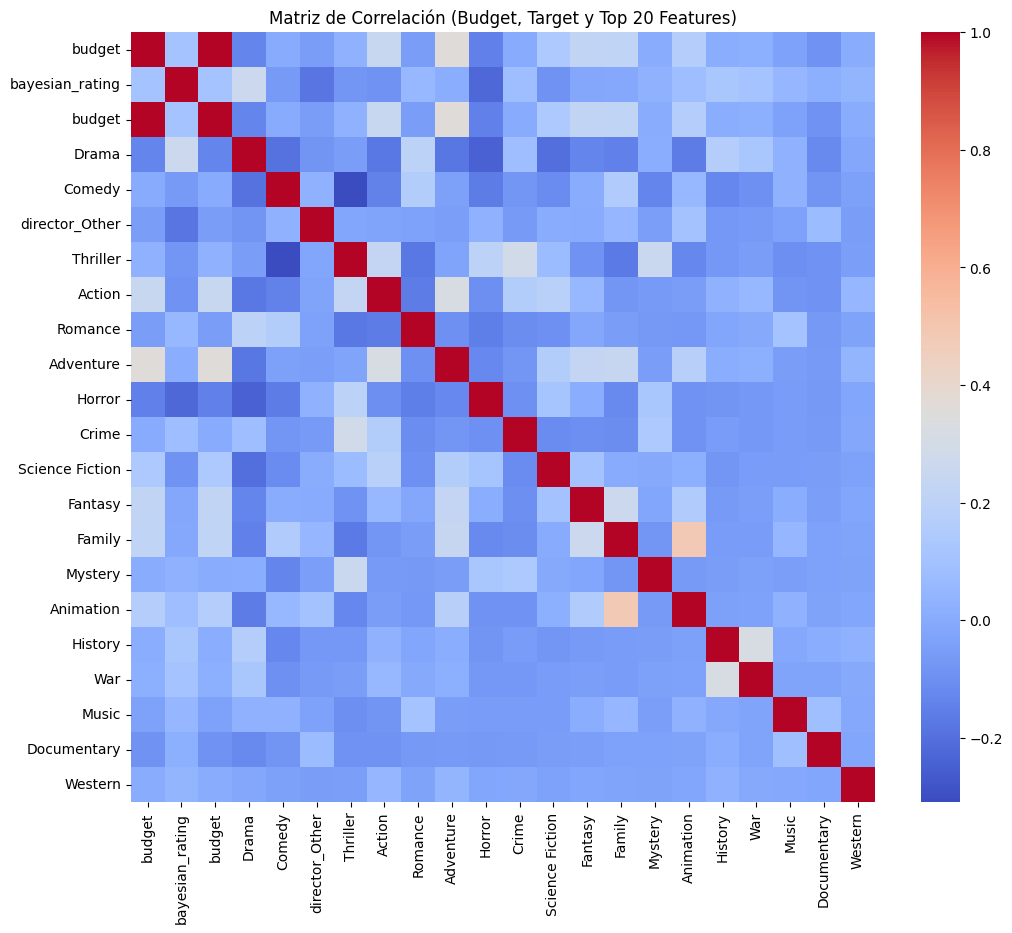


--- Top 10 Correlaciones con Media Bayesiana (Target) ---
Drama                         0.262539
History                       0.120535
War                           0.106388
budget                        0.105787
Crime                         0.082720
Animation                     0.081851
director_Alfred Hitchcock     0.075140
director_Martin Scorsese      0.071000
director_Christopher Nolan    0.068206
director_Steven Spielberg     0.063596
Name: bayesian_rating, dtype: float64


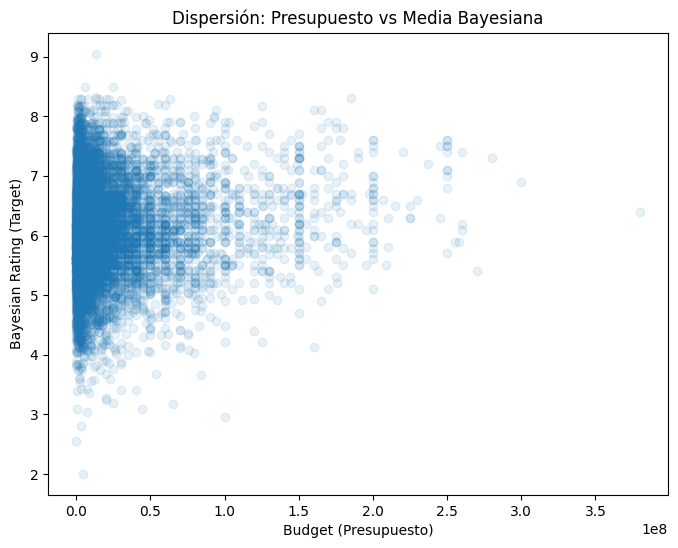

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de Correlación
# Calculamos la correlación solo para las variables más relevantes (budget y géneros)
# Para no sobrecargar la matriz, seleccionamos las N features con mayor varianza.
top_features = df_model.drop(columns=['bayesian_rating']).var().nlargest(20).index
features_to_plot = ['budget', 'bayesian_rating'] + list(top_features)

correlation_matrix = df_model[features_to_plot].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación (Budget, Target y Top 20 Features)')
plt.show()


# Correlación del Target con las Features
correlations = df_model.corr()['bayesian_rating'].sort_values(ascending=False)
print("\n--- Top 10 Correlaciones con Media Bayesiana (Target) ---")
print(correlations.head(11).iloc[1:]) # Excluir bayesian_rating con 1.0

# Gráfico de dispersión para Budget vs Target
plt.figure(figsize=(8, 6))
plt.scatter(df_model['budget'], df_model['bayesian_rating'], alpha=0.1)
plt.xlabel('Budget (Presupuesto)')
plt.ylabel('Bayesian Rating (Target)')
plt.title('Dispersión: Presupuesto vs Media Bayesiana')
plt.show()

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# Reiniciamos el índice antes de stratificar para evitar el KeyError
df_model = df_model.reset_index(drop=True)

# Crear categorías de presupuesto para la estratificación
# Definimos los tramos (bins) de presupuesto
df_model['budget_cat'] = pd.cut(df_model['budget'],
                               bins=[0, 1e6, 10e6, 50e6, 100e6, np.inf],
                               labels=[1, 2, 3, 4, 5],
                               right=False) # Incluir 0 en el primer tramo

# Inicializar el Splitter (20% para test)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Generar los índices y crear los conjuntos
for train_index, test_index in split.split(df_model, df_model['budget_cat']):
    strat_train_set = df_model.loc[train_index]
    strat_test_set = df_model.loc[test_index]

# Separar X e y y eliminar la columna auxiliar
X_train = strat_train_set.drop(["bayesian_rating", "budget_cat"], axis=1)
y_train = strat_train_set["bayesian_rating"]
X_test = strat_test_set.drop(["bayesian_rating", "budget_cat"], axis=1)
y_test = strat_test_set["bayesian_rating"]

In [18]:
# Usaremos un Pipeline para escalar la única feature numérica ('budget') y dejar las categóricas sin tocar.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Aunque OHE ya lo hicimos

# Solo escalamos la columna 'budget'
numerical_features = ['budget']
# El resto son features One-Hot, no necesitan escalado
passthrough_features = X_train.columns.drop(numerical_features).tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', 'passthrough', passthrough_features)
    ])

# Aplicar la transformación a los conjuntos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convertir de nuevo a DataFrame para facilitar la visualización (opcional)
X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns)
X_test_processed = pd.DataFrame(X_test_processed, columns=X_test.columns)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)
predictions_lr = lin_reg.predict(X_test_processed)

# Evaluación
rmse_lr = np.sqrt(mean_squared_error(y_test, predictions_lr))
r2_lr = r2_score(y_test, predictions_lr)

# Random Forest
# Un modelo más complejo puede capturar mejor las relaciones no lineales
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_reg.fit(X_train_processed, y_train)
predictions_rf = rf_reg.predict(X_test_processed)

# Evaluación
rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))
r2_rf = r2_score(y_test, predictions_rf)

# Comparación de Resultados
results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print("\nComparación de Modelos")
print(results.to_markdown(index=False))


Comparación de Modelos
| Modelo           |     RMSE |   R2 Score |
|:-----------------|---------:|-----------:|
| Regresión Lineal | 0.739729 |   0.196039 |
| Random Forest    | 0.761636 |   0.147715 |
